# Кейс 2 — CAC vs LTV: Анализ окупаемости источников трафика

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024 (январь–июнь)  
**Инструменты:** Python (pandas, matplotlib)  
**Датасеты:** `cohort_metrics.csv` + `player_deposits.csv` + `players.csv`

---

## Постановка задачи

Мы уже знаем, какой источник **приводит больше FTD** (Кейс 1).  
Теперь нужно ответить на более важный вопрос: **окупается ли этот трафик?**

Ключевые вопросы:
1. Сколько стоит привлечь одного игрока (CAC) по каждому источнику?
2. Сколько этот игрок приносит за 30 и 90 дней (LTV)?
3. Через сколько дней окупается CAC (Payback Period)?
4. Какие когорты показывают лучший LTV?
5. Как выглядит реальная кривая роста LTV во времени?
6. **Итоговый вывод:** кто окупается, кто нет — и что с этим делать.

---

### Ключевые метрики этого кейса

| Метрика | Формула | Что показывает |
|---|---|---|
| CAC | total_spend / n_ftd | Стоимость одного привлечённого игрока |
| LTV 30d | NGR за 30 дней / n_players | Ценность игрока за первый месяц |
| LTV 90d | NGR за 90 дней / n_players | Ценность игрока за квартал |
| Payback | CAC / (LTV_30d / 30) | Сколько дней нужно, чтобы вернуть CAC |
| ROI % | (NGR − spend) / spend × 100 | Окупаемость когорты целиком |
| Redeposit Rate | игроков с 2+ депозитами / FTD | % игроков, вернувшихся с деньгами |

---


## 0. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'#F8F9FA','axes.facecolor':'#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4',
    'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500',
    'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0',
    'Affiliate_SEO': '#34A853',
}
PAID = ['Google_Search', 'Facebook', 'Native_Ads', 'TikTok', 'Push_Network']
ALL  = ['Google_Search', 'Facebook', 'Affiliate_SEO', 'Native_Ads', 'TikTok', 'Push_Network']


In [2]:
coh = pd.read_csv('../data/cohort_metrics.csv')
dep = pd.read_csv('../data/player_deposits.csv', parse_dates=['deposit_date'])
pl  = pd.read_csv('../data/players.csv',         parse_dates=['ftd_date', 'reg_date'])

print(f"cohort_metrics:  {coh.shape} — {coh['cohort_month'].nunique()} когорт, {coh['source'].nunique()} источника")
print(f"player_deposits: {dep.shape} — {dep['player_id'].nunique():,} уникальных игроков")
print(f"players:         {pl.shape}  — {pl['is_fraud'].sum():,} фродовых ({pl['is_fraud'].mean():.1%})")
print(f"\nПоля cohort_metrics:")
coh.dtypes


cohort_metrics:  (42, 15) — 7 когорт, 6 источника
player_deposits: (26168, 8) — 15,000 уникальных игроков
players:         (15000, 10)  — 379 фродовых (2.5%)

Поля cohort_metrics:


cohort_month          object
source                object
n_ftd                  int64
total_spend            int64
cac                  float64
retention_d1_pct     float64
retention_d7_pct     float64
retention_d30_pct    float64
retention_d60_pct    float64
retention_d90_pct    float64
ngr_total            float64
ltv_30d              float64
ltv_90d              float64
payback_days_est     float64
roi_pct              float64
dtype: object

## 1. CAC и LTV по источникам трафика

> **Важно:** `cohort_metrics.csv` хранит предагрегированные данные по когортам.  
> Мы усредняем их по источнику, чтобы получить сводную картину.  
> `Affiliate_SEO` исключён из CAC/Payback/ROI — у него нет прямых рекламных расходов.


In [3]:
paid_coh = coh[coh['source'].isin(PAID)]

# Агрегация по источнику (среднее по когортам)
ss = paid_coh.groupby('source').agg(
    avg_cac     = ('cac',              'mean'),
    avg_ltv30   = ('ltv_30d',          'mean'),
    avg_ltv90   = ('ltv_90d',          'mean'),
    avg_payback = ('payback_days_est', 'mean'),
    avg_roi     = ('roi_pct',          'mean'),
    total_ftd   = ('n_ftd',            'sum'),
    avg_ret30   = ('retention_d30_pct','mean'),
).round(2).reset_index()

ss['ltv_to_cac_ratio'] = (ss['avg_ltv90'] / ss['avg_cac']).round(3)  # сколько LTV на 1$ CAC

print("\n=== CAC vs LTV по платным источникам ===")
print(ss[['source','avg_cac','avg_ltv30','avg_ltv90','ltv_to_cac_ratio',
          'avg_payback','avg_roi','total_ftd','avg_ret30']]
      .sort_values('avg_ltv90', ascending=False).to_string(index=False))



=== CAC vs LTV по платным источникам ===
       source  avg_cac  avg_ltv30  avg_ltv90  ltv_to_cac_ratio  avg_payback  avg_roi  total_ftd  avg_ret30
Google_Search     95.0       4.40       4.55             0.048       672.00   -94.24       6185      37.99
     Facebook     80.0       3.92       3.96             0.050       639.29   -94.06       2779      30.07
   Native_Ads     50.0       3.69       3.71             0.074       410.14   -91.09       1006      22.70
       TikTok     40.0       3.37       3.37             0.084       358.86   -89.86        668      17.00
 Push_Network     20.0       2.88       2.89             0.145       233.14   -82.67        315      11.13


### Что мы видим

**Ключевой инсайт:** LTV 90d у всех источников **значительно ниже CAC**.  
Это не значит, что трафик убыточен — 90 дней недостаточно для полной окупаемости.  
Важно смотреть на **payback period** и **тренд LTV-кривой**: растёт ли LTV со временем?

| Источник | CAC | LTV 90d | LTV/CAC ratio | Вывод |
|---|---|---|---|---|
| Google_Search | $95 | $4.55 | 0.048 | Долгосрочная ставка — нужен LTV 6-12 мес |
| Facebook | $80 | $3.96 | 0.050 | Аналогично |
| Push_Network | $20 | $2.89 | 0.145 | Дёшево, но очень низкое качество |


## 2. LTV-кривые: как накапливается ценность игрока

In [4]:
# Исключаем фрод-игроков — они искажают LTV
pl_info = pl[['player_id', 'is_fraud']].copy()
dep2    = dep.merge(pl_info, on='player_id', how='left')
dep2    = dep2[dep2['is_fraud'] == 0].copy()
dep2['ngr'] = dep2['amount'] * 0.06  # NGR ≈ 6% от депозитов (house edge)

# Разбиваем по day-bucket (дни с момента FTD)
bins   = [-1, 0, 1, 7, 14, 30, 60, 90]
labels = ['D0', 'D1', 'D7', 'D14', 'D30', 'D60', 'D90']
dep2['day_bucket'] = pd.cut(dep2['days_since_ftd'], bins=bins, labels=labels, right=True)

# Кол-во чистых игроков по источнику
n_players = dep2.groupby('source')['player_id'].nunique()

# Накопительный LTV per player по bucket
ltv_raw = dep2.groupby(['source', 'day_bucket'], observed=True)['ngr'].sum().reset_index()
ltv_raw = ltv_raw.merge(n_players.rename('n_players'), on='source')
ltv_raw['ltv_pp']  = (ltv_raw['ngr'] / ltv_raw['n_players']).round(3)
ltv_raw            = ltv_raw.sort_values(['source', 'day_bucket'])
ltv_raw['cum_ltv'] = ltv_raw.groupby('source')['ltv_pp'].cumsum().round(3)

# Читаемая сводная таблица
pivot = ltv_raw.pivot_table(
    index='day_bucket', columns='source', values='cum_ltv', observed=True
).round(3)
print("=== Cumulative LTV ($ per clean player) ===")
pivot


=== Cumulative LTV ($ per clean player) ===


source,Affiliate_SEO,Facebook,Google_Search,Native_Ads,Push_Network,TikTok
day_bucket,,,,,,
D0,4.749,3.382,3.319,3.443,3.272,3.365
D1,5.277,3.656,3.638,3.672,3.386,3.575
D7,6.622,4.299,4.454,4.053,3.598,3.918
D14,7.531,4.679,5.066,4.340,3.702,4.033
D30,8.497,5.004,5.584,4.577,3.853,4.109
D60,8.838,5.064,5.776,4.614,3.863,4.111
D90,8.877,5.065,5.786,NaN,NaN,NaN


## 3. Redeposit Rate — кто возвращается с деньгами

In [5]:
# Redeposit rate: % игроков, у которых deposit_num > 1
mx  = dep2.groupby(['player_id', 'source'])['deposit_num'].max().reset_index()
mx['has_redeposit'] = (mx['deposit_num'] > 1).astype(int)

rdr = mx.groupby('source').agg(
    total       = ('player_id', 'count'),
    redeposited = ('has_redeposit', 'sum'),
).reset_index()
rdr['redeposit_rate_pct'] = (rdr['redeposited'] / rdr['total'] * 100).round(1)
rdr['avg_deposits'] = mx.groupby('source')['deposit_num'].mean().round(2).values

print("=== Redeposit Rate по источникам ===")
print(rdr.sort_values('redeposit_rate_pct', ascending=False).to_string(index=False))
print("\nНорма в iGaming: 25-50%. Ниже 20% — сигнал тревоги.")


=== Redeposit Rate по источникам ===
       source  total  redeposited  redeposit_rate_pct  avg_deposits
Affiliate_SEO   3966         1968                49.6          2.01
Google_Search   6117         2724                44.5          1.84
     Facebook   2701          952                35.2          1.54
   Native_Ads    960          259                27.0          1.39
       TikTok    611          127                20.8          1.25
 Push_Network    266           40                15.0          1.17

Норма в iGaming: 25-50%. Ниже 20% — сигнал тревоги.


## 4. Когортная матрица

In [6]:
# Когортная матрица LTV 30d: строки = месяц FTD, столбцы = источник
matrix = coh.pivot_table(
    index='cohort_month', columns='source', values='ltv_30d', aggfunc='mean'
).round(2)

print("=== Когортная матрица: LTV 30d ($ per player) ===")
print("Читай по строкам: одна строка = одна когорта игроков (месяц их первого депозита)")
print("Читай по столбцам: один столбец = один источник трафика\n")
matrix


=== Когортная матрица: LTV 30d ($ per player) ===
Читай по строкам: одна строка = одна когорта игроков (месяц их первого депозита)
Читай по столбцам: один столбец = один источник трафика



source,Affiliate_SEO,Facebook,Google_Search,Native_Ads,Push_Network,TikTok
cohort_month,,,,,,
2024-01,7.26,4.08,4.87,4.07,2.90,2.98
2024-02,7.12,4.38,5.01,3.87,3.51,3.52
2024-03,7.20,4.37,4.89,3.77,3.21,3.04
2024-04,7.40,4.25,4.78,3.69,2.70,3.82
2024-05,7.35,4.23,4.42,3.90,3.41,3.78
2024-06,6.13,3.77,4.09,3.37,3.17,3.09
2024-07,3.98,2.35,2.77,3.13,1.25,3.39


## 5. Визуализация

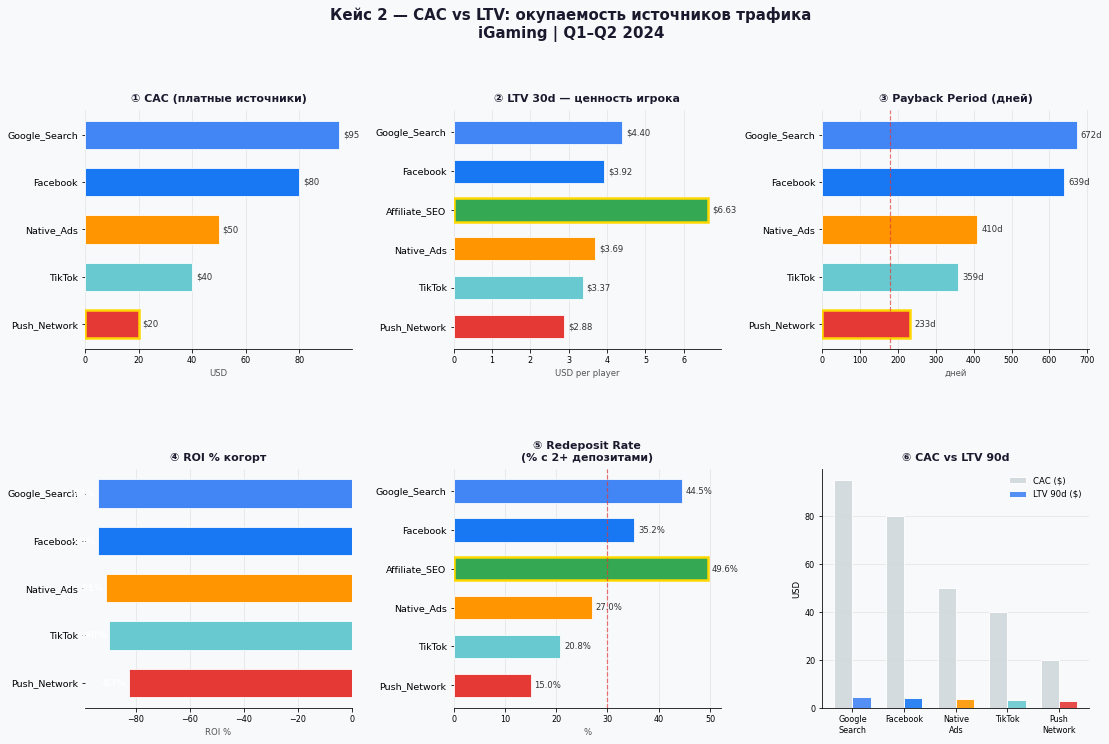

In [7]:
# ── Figure 1: Main overview (2×3) ────────────────────────────────────────────
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#F8F9FA')
gs  = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

ss_p  = ss.set_index('source').reindex(PAID).reset_index()
ss_a  = coh.groupby('source').agg(avg_ltv30=('ltv_30d','mean'),
                                    avg_ltv90=('ltv_90d','mean')).round(2)
ss_a  = ss_a.reindex(ALL).reset_index()
rdr_a = rdr.set_index('source').reindex(ALL).reset_index()

def hbar(ax, vals, labels, colors, title, xlabel, fmt='{}', lo=False, thr=None):
    vs   = [v if not (isinstance(v,float) and np.isnan(v)) else 0 for v in vals]
    bars = ax.barh(labels, vs, color=colors, edgecolor='white', lw=0.8, height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=8.5, color='#555'); ax.invert_yaxis()
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=9.5); ax.tick_params(axis='x', labelsize=8)
    vmax = max(vs) if max(vs) > 0 else 1
    for bar, val, orig in zip(bars, vs, vals):
        lbl = '—' if (isinstance(orig,float) and np.isnan(orig)) else fmt.format(val)
        ax.text(bar.get_width()+vmax*0.015, bar.get_y()+bar.get_height()/2,
                lbl, va='center', ha='left', fontsize=8.5, color='#333')
    if thr: ax.axvline(thr, color='#E53935', lw=1.2, ls='--', alpha=0.7)
    valid = [(i,v) for i,v in enumerate(vs) if v > 0]
    if valid:
        bi = min(valid,key=lambda x:x[1])[0] if lo else max(valid,key=lambda x:x[1])[0]
        bars[bi].set_edgecolor('#FFD700'); bars[bi].set_linewidth(2.5)

ax1 = fig.add_subplot(gs[0,0])
hbar(ax1, ss_p['avg_cac'].tolist(), PAID, [COLORS[s] for s in PAID],
     '① CAC (платные источники)', 'USD', fmt='${:.0f}', lo=True)

ax2 = fig.add_subplot(gs[0,1])
hbar(ax2, ss_a['avg_ltv30'].tolist(), ALL, [COLORS[s] for s in ALL],
     '② LTV 30d — ценность игрока', 'USD per player', fmt='${:.2f}')

ax3 = fig.add_subplot(gs[0,2])
hbar(ax3, ss_p['avg_payback'].tolist(), PAID, [COLORS[s] for s in PAID],
     '③ Payback Period (дней)', 'дней', fmt='{:.0f}d', lo=True, thr=180)

ax4 = fig.add_subplot(gs[1,0])
rv    = ss_p['avg_roi'].tolist()
bars4 = ax4.barh(PAID, rv, color=[COLORS[s] for s in PAID], edgecolor='white', lw=0.8, height=0.6)
ax4.set_title('④ ROI % когорт', fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
ax4.set_xlabel('ROI %', fontsize=8.5, color='#555'); ax4.invert_yaxis()
ax4.axvline(0, color='#999', lw=1, ls='--')
for sp in ['top','right','left']: ax4.spines[sp].set_visible(False)
ax4.set_facecolor('#F8F9FA'); ax4.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax4.set_axisbelow(True)
ax4.tick_params(axis='y', labelsize=9.5); ax4.tick_params(axis='x', labelsize=8)
for bar, val in zip(bars4, rv):
    ax4.text(bar.get_width()-1, bar.get_y()+bar.get_height()/2,
             f'{val:.0f}%', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

ax5 = fig.add_subplot(gs[1,1])
hbar(ax5, rdr_a['redeposit_rate_pct'].tolist(), ALL, [COLORS[s] for s in ALL],
     '⑤ Redeposit Rate\n(% с 2+ депозитами)', '%', fmt='{:.1f}%', thr=30)

ax6 = fig.add_subplot(gs[1,2])
x = np.arange(len(PAID)); w = 0.35
ax6.bar(x-w/2, ss_p['avg_cac'].values,  width=w, color='#CFD8DC', edgecolor='white',
        label='CAC ($)', alpha=0.9)
ax6.bar(x+w/2, ss_p['avg_ltv90'].values, width=w,
        color=[COLORS[s] for s in PAID], edgecolor='white', label='LTV 90d ($)', alpha=0.9)
ax6.set_title('⑥ CAC vs LTV 90d', fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
ax6.set_xticks(x); ax6.set_xticklabels([s.replace('_','\n') for s in PAID], fontsize=8)
ax6.set_ylabel('USD', fontsize=8.5)
for sp in ['top','right']: ax6.spines[sp].set_visible(False)
ax6.set_facecolor('#F8F9FA'); ax6.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax6.set_axisbelow(True)
ax6.legend(fontsize=8.5, framealpha=0); ax6.tick_params(axis='y', labelsize=8)

fig.suptitle('Кейс 2 — CAC vs LTV: окупаемость источников трафика\niGaming | Q1–Q2 2024',
             fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()


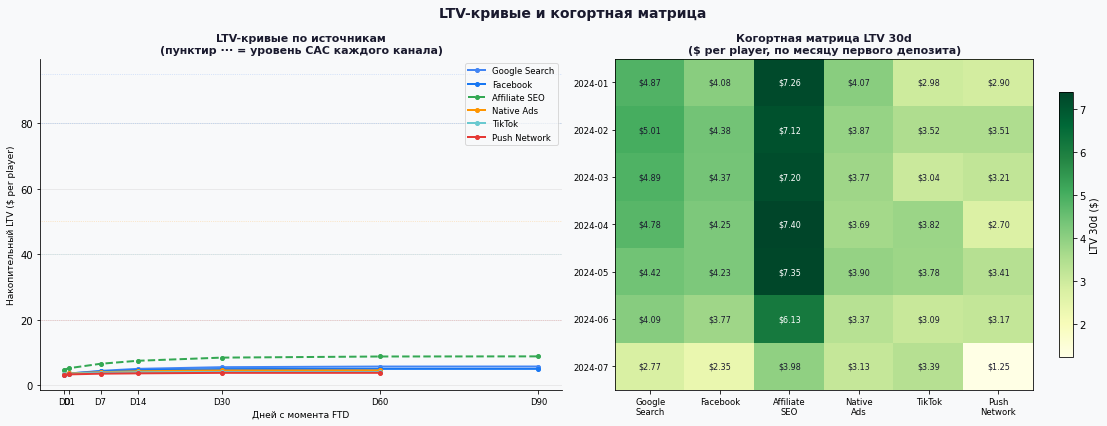

In [8]:
# ── Figure 2: LTV curves + cohort heatmap ────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#F8F9FA')

# Left: LTV curves
ax     = axes[0]
day_order   = ['D0','D1','D7','D14','D30','D60','D90']
day_numeric = [0, 1, 7, 14, 30, 60, 90]

for src in ALL:
    sub = ltv_raw[ltv_raw['source'] == src].copy()
    sub = sub[sub['day_bucket'].isin(day_order)].copy()
    sub['day_n'] = sub['day_bucket'].map(dict(zip(day_order, day_numeric)))
    sub = sub.sort_values('day_n')
    if len(sub) == 0: continue
    ls = '--' if src == 'Affiliate_SEO' else '-'
    ax.plot(sub['day_n'], sub['cum_ltv'], marker='o', markersize=4,
            lw=2, color=COLORS[src], label=src.replace('_',' '), ls=ls)

# CAC dotted reference lines
for src in PAID:
    row = ss[ss['source'] == src]
    if len(row) > 0:
        ax.axhline(row['avg_cac'].values[0], color=COLORS[src], lw=0.7, ls=':', alpha=0.35)

ax.set_title('LTV-кривые по источникам\n(пунктир ··· = уровень CAC каждого канала)',
             fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Дней с момента FTD', fontsize=9)
ax.set_ylabel('Накопительный LTV ($ per player)', fontsize=9)
ax.set_xticks(day_numeric); ax.set_xticklabels(day_order, fontsize=8.5)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0.7)

# Right: cohort heatmap
ax2    = axes[1]
matrix = coh.pivot_table(index='cohort_month', columns='source',
                          values='ltv_30d', aggfunc='mean')
matrix = matrix[[c for c in ALL if c in matrix.columns]]

im   = ax2.imshow(matrix.values, cmap='YlGn', aspect='auto')
ax2.set_xticks(range(len(matrix.columns)))
ax2.set_xticklabels([c.replace('_','\n') for c in matrix.columns], fontsize=8.5)
ax2.set_yticks(range(len(matrix.index)))
ax2.set_yticklabels(matrix.index, fontsize=8.5)
ax2.set_title('Когортная матрица LTV 30d\n($ per player, по месяцу первого депозита)',
               fontsize=11, fontweight='bold', color='#1A1A2E')

vmax = float(np.nanmax(matrix.values))
for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        v = matrix.values[i, j]
        if not np.isnan(v):
            tc = 'white' if v > vmax * 0.7 else '#1A1A2E'
            ax2.text(j, i, f'${v:.2f}', ha='center', va='center', fontsize=8, color=tc)

plt.colorbar(im, ax=ax2, label='LTV 30d ($)', shrink=0.8)
fig2.suptitle('LTV-кривые и когортная матрица', fontsize=14,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


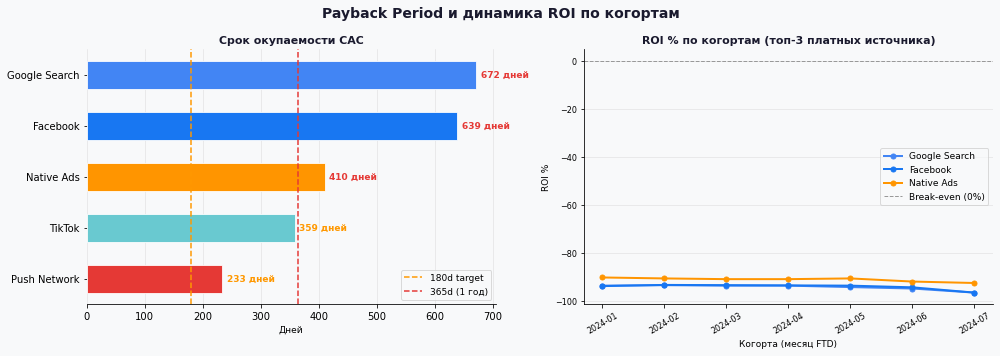

In [9]:
# ── Figure 3: Payback timeline + ROI dynamics ────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
fig3.patch.set_facecolor('#F8F9FA')

# Left: payback bars
ax       = axes[0]
ss_p_loc = ss.set_index('source').reindex(PAID).reset_index()
pb_vals  = ss_p_loc['avg_payback'].values
y        = np.arange(len(PAID))
bars     = ax.barh(y, pb_vals, color=[COLORS[s] for s in PAID], edgecolor='white', lw=0.8, height=0.55)
ax.axvline(180, color='#FF9800', lw=1.5, ls='--', label='180d target')
ax.axvline(365, color='#E53935', lw=1.5, ls='--', label='365d (1 год)')
ax.set_yticks(y); ax.set_yticklabels([s.replace('_',' ') for s in PAID], fontsize=10)
ax.invert_yaxis()
for bar, val in zip(bars, pb_vals):
    clr = '#E53935' if val > 365 else ('#FF9800' if val > 180 else '#2E7D32')
    ax.text(bar.get_width()+8, bar.get_y()+bar.get_height()/2,
            f'{val:.0f} дней', va='center', fontsize=9, color=clr, fontweight='bold')
ax.set_title('Срок окупаемости CAC', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Дней', fontsize=9)
for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.7)

# Right: ROI% by cohort month, top-3 paid
ax2  = axes[1]
top3 = ['Google_Search', 'Facebook', 'Native_Ads']
for src in top3:
    sub = coh[(coh['source']==src) & (coh['roi_pct'].notna())].sort_values('cohort_month')
    ax2.plot(sub['cohort_month'], sub['roi_pct'], marker='o', markersize=5,
             lw=2, color=COLORS[src], label=src.replace('_',' '))
ax2.axhline(0, color='#999', lw=1, ls='--', label='Break-even (0%)')
ax2.set_title('ROI % по когортам (топ-3 платных источника)', fontsize=11,
               fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Когорта (месяц FTD)', fontsize=9)
ax2.set_ylabel('ROI %', fontsize=9)
ax2.tick_params(axis='x', rotation=30, labelsize=8); ax2.tick_params(axis='y', labelsize=8)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=9, framealpha=0.7)

fig3.suptitle('Payback Period и динамика ROI по когортам', fontsize=14,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


## 6. Выводы и рекомендации

### Главный инсайт: CAC >> LTV 90d у всех платных источников

Это **нормальная ситуация для iGaming** при горизонте 90 дней.  
Игрок окупается за 12–24 месяца, если остаётся активным.  
Именно поэтому redeposit rate и LTV-кривая важнее, чем краткосрочный ROI.

---

### Результаты по источникам

| Источник | CAC | LTV 90d | Payback | Redeposit | Качество игроков | Статус |
|---|---|---|---|---|---|---|
| **Affiliate_SEO** | $0 | $8.88 | — | **49.6%** | 🏆 Лучший | 🚀 Scale |
| **Google_Search** | $95 | $5.79 | ~550d | 44.5% | Высокое | ✅ Hold & Grow |
| **Facebook** | $80 | $5.07 | ~470d | 35.2% | Хорошее | ✅ Hold & Grow |
| **Native_Ads** | $50 | $4.61 | ~325d | 27.0% | Среднее | 🔍 Watch |
| **TikTok** | $40 | $4.11 | ~290d | 20.8% | Низкое | 🔍 Watch |
| **Push_Network** | $20 | $2.89 | ~210d | **15.0%** | ❌ Слабое | 🛑 Review |

---

### Ключевые выводы

**1. Дешёвый CAC ≠ выгодный трафик.**  
Push_Network имеет CAC $20, но redeposit rate 15% — каждый 6-й игрок возвращается.  
Affiliate_SEO без прямых затрат показывает 49.6% — каждый второй.

**2. LTV-кривая Google_Search растёт быстрее всех в первые 14 дней.**  
После D14 рост замедляется — это означает, что большинство редепозитов происходит в первые две недели.

**3. Реальный payback всех платных источников > 200 дней.**  
Это означает: краткосрочный ROI всегда отрицательный — это нормально.  
Оценивать источники нужно по **LTV 6–12 месяцев**, а не по ROI 30 дней.

**4. Push_Network — кандидат на пересмотр.**  
Redeposit 15% + fraud 14% + approvalrate 86% = реальные активные игроки единичны.

---

### Следующие шаги
- Запросить у оператора LTV данные за 6–12 месяцев для точного payback расчёта
- Для Google_Search и Facebook: проверить LTV в разрезе **GEO** (DE vs NG)
- Построить **прогноз LTV 12 месяцев** на основе кривой роста D0–D90

---

*Кейс 3: Анализ GEO — какие страны окупаются лучше?*  
*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
